### what is bias
### what is variance
### what is underfitting
### what is overfitting

# Bias, Variance, noice

# Regression

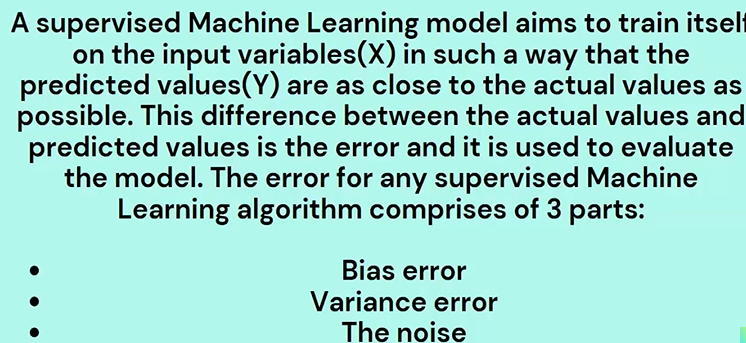

In [6]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 153220.png")

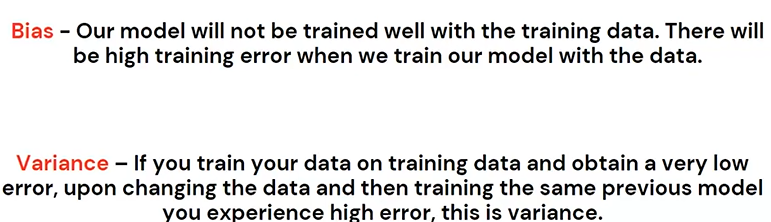

In [33]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 153838.png")

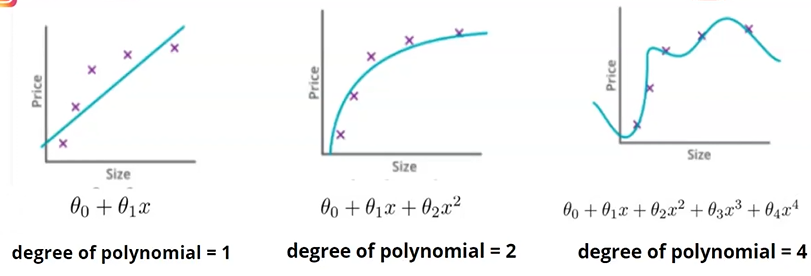

In [35]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 153902.png")

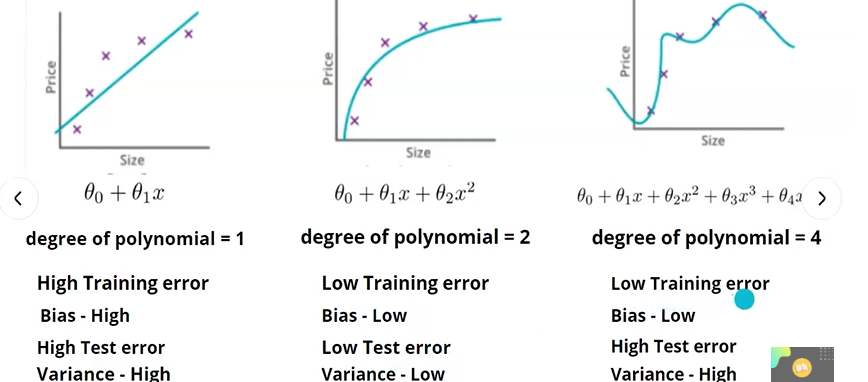

In [37]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 154306.png")

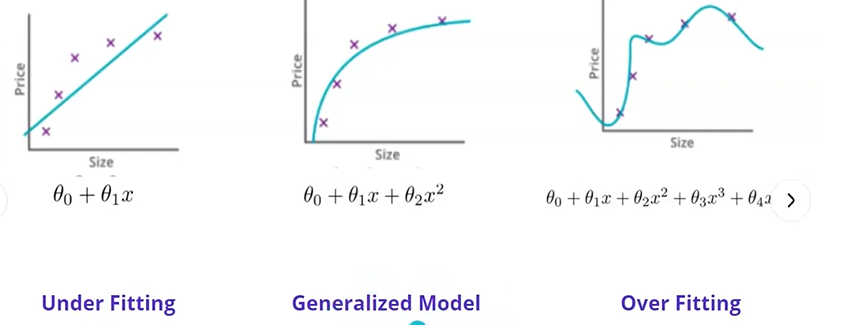

In [39]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 154810.png")

# Classification 

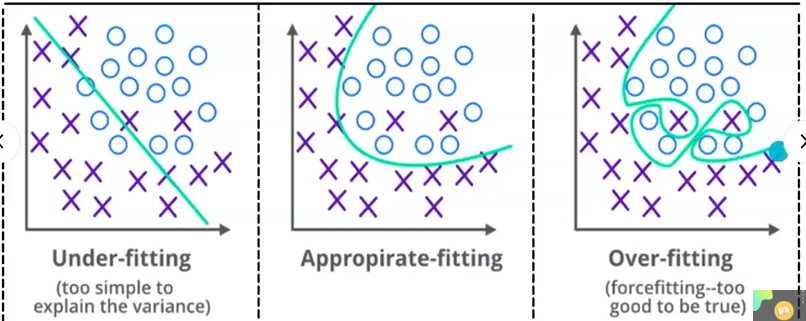

In [41]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 155208.png")

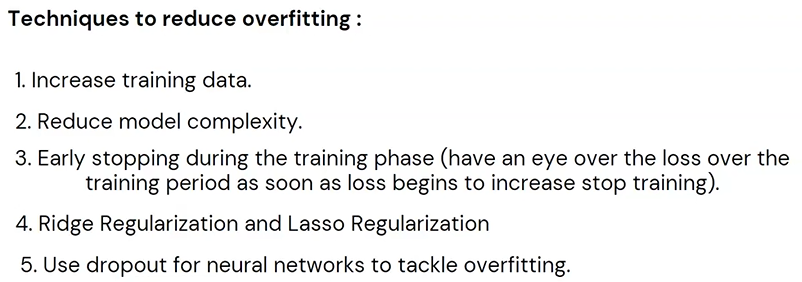

In [43]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-11 155757.png")

# How to find the Bias 

 Does High MSE Mean Predictions Are Close?

If MSE is high, it means the predictions are far from the actual values → the model is not accurate.
If MSE is low, it means predictions are close to the actual values → the model is more accurate.

⚠️ Common Mistake:

If you're thinking in percentages (like 90% or 50%), you're probably mixing it with R² score or accuracy metrics, which are used in classification problems.
MSE doesn't give percentages; it's an absolute error value.

✅ In Summary

MSE can't be negative.
MSE is not a percentage.
Low MSE = Model is predicting values close to actual values.
High MSE = Model is making big prediction errors.


In [55]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample dataset
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([3, 6, 9, 12, 15])  # Perfect linear relationship (y = 3 * x)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)
print(y_pred)
# Calculate Bias (difference between mean of predictions and actual values)
bias = np.mean(y_pred - y)
print(f"Bias: {bias}")

# Also calculate Mean Squared Error (for reference)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
X

[ 3.  6.  9. 12. 15.]
Bias: -8.881784197001252e-16
Mean Squared Error (MSE): 2.0510383535746308e-30


array([[1],
       [2],
       [3],
       [4],
       [5]])

# how to find the varince

### Great question! Let's break down how to find variance and understand what it means in terms of model performance—especially when we say a model has high variance (overfitting). 

In [61]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Sample Data
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

# Model
model = LinearRegression()

# Cross-Validation (5-fold)
scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)

# Convert to positive MSE
mse_scores = -scores
print(f"MSE Scores from each fold: {mse_scores}")

# Variance of MSE across folds
variance = np.var(mse_scores)
print(f"Variance in MSE: {variance}")


MSE Scores from each fold: [0.00000000e+00 3.15544362e-30 6.31088724e-30 1.26217745e-29
 0.00000000e+00]
Variance in MSE: 2.230328675585433e-59


In [63]:
from sklearn.metrics import mean_squared_error

# Split Data into Train and Test Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Calculate Errors
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")

# Check the gap (higher gap indicates higher variance)
print(f"Gap between Train and Test Error: {test_mse - train_mse}")


Train MSE: 2.732839564515648e-30
Test MSE: 2.3665827156630354e-30
Gap between Train and Test Error: -3.6625684885261272e-31


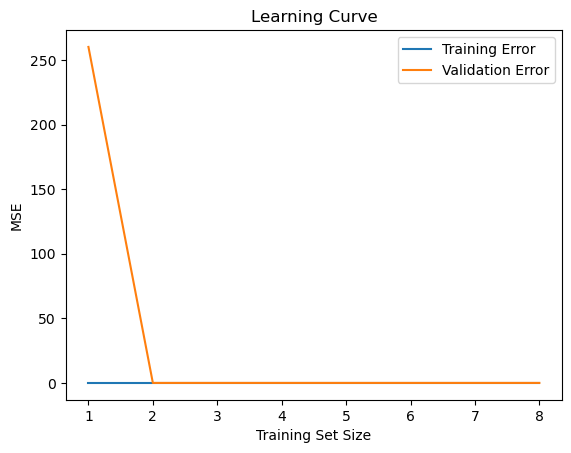

In [65]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='neg_mean_squared_error')

# Convert negative MSE to positive
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label="Training Error")
plt.plot(train_sizes, test_scores_mean, label="Validation Error")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.title("Learning Curve")
plt.show()
